# 03 - Baseline Forecasting

This notebook reads processed baseline predictions and metrics. It does not rerun raw data preparation or backtesting.

In [1]:
from pathlib import Path
import os
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))
import pandas as pd
import matplotlib.pyplot as plt
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
REPORTS = PROJECT_ROOT / 'reports'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
store_pred = pd.read_parquet(PROCESSED / 'baseline_predictions_store_department.parquet')
selected_pred = pd.read_parquet(PROCESSED / 'baseline_predictions_selected_series.parquet')
predictions = pd.concat([store_pred, selected_pred], ignore_index=True)
metrics = pd.read_parquet(PROCESSED / 'baseline_metrics.parquet')
summary = pd.read_csv(REPORTS / 'baseline_metrics_summary.csv')
by_pattern = pd.read_csv(REPORTS / 'baseline_metrics_by_pattern.csv')

## Model Comparison By MAE, WAPE, And RMSSE

,dataset,model,mean_mae,median_mae,weighted_mae,mean_rmse,median_rmse,weighted_rmse,mean_wape,median_wape,weighted_wape,mean_rmsse,median_rmsse,weighted_rmsse,mean_smape,median_smape,weighted_smape,series_count,actual_volume
17,store_department,seasonal_naive_28,82.208163,61.785714,151.075280,106.844350,81.152214,195.659272,0.186573,0.155927,0.136728,1.024540,0.969436,0.913382,18.933764,16.064755,13.969457,70,3535361.0
18,store_department,seasonal_naive_7,93.033163,61.946429,178.500824,118.176494,82.153204,223.986789,0.195158,0.165149,0.154732,1.071332,0.977981,1.011675,19.637606,16.744501,15.955323,70,3535361.0
13,store_department,moving_average_28,104.985107,68.642857,209.597042,130.396423,83.670979,260.201587,0.196644,0.188709,0.174611,1.089404,1.023299,1.119851,19.609734,18.635282,17.324997,70,3535361.0
11,store_department,croston_sba,107.706916,70.201739,218.613978,137.122203,86.498110,277.454801,0.197593,0.189527,0.179138,1.124686,1.069360,1.179851,19.745924,18.898479,17.869142,70,3535361.0
10,store_department,croston_classic,108.125164,71.055364,216.740052,132.351967,87.295469,264.396394,0.200532,0.191730,0.179833,1.098819,1.034779,1.135032,19.905720,19.033560,17.820496,70,3535361.0
19,store_department,tsb,108.125940,71.054124,216.737877,132.348475,87.296962,264.387400,0.200536,0.191731,0.179835,1.098799,1.034963,1.134999,19.905963,19.033564,17.820483,70,3535361.0
14,store_department,moving_average_7,112.910957,72.484694,229.307833,141.481471,89.667572,285.666657,0.207432,0.194332,0.187793,1.159849,1.067733,1.214472,20.590793,19.431439,18.768364,70,3535361.0
16,store_department,seasonal_average_weekday,127.311677,73.599336,232.884325,147.440512,91.055082,269.034397,0.242208,0.231670,0.211744,1.346663,1.165682,1.328539,26.943242,25.235689,23.919788,70,3535361.0
12,store_department,historical_mean,143.165637,80.581137,278.346416,177.467025,106.675053,342.134243,0.259918,0.244991,0.238113,1.524628,1.308763,1.576205,28.112506,25.109315,25.855132,70,3535361.0
15,store_department,naive,172.649490,107.267857,341.105129,197.885194,123.305260,390.050114,0.315845,0.264185,0.287150,1.635029,1.407986,1.694669,29.355270,26.298758,26.512039,70,3535361.0


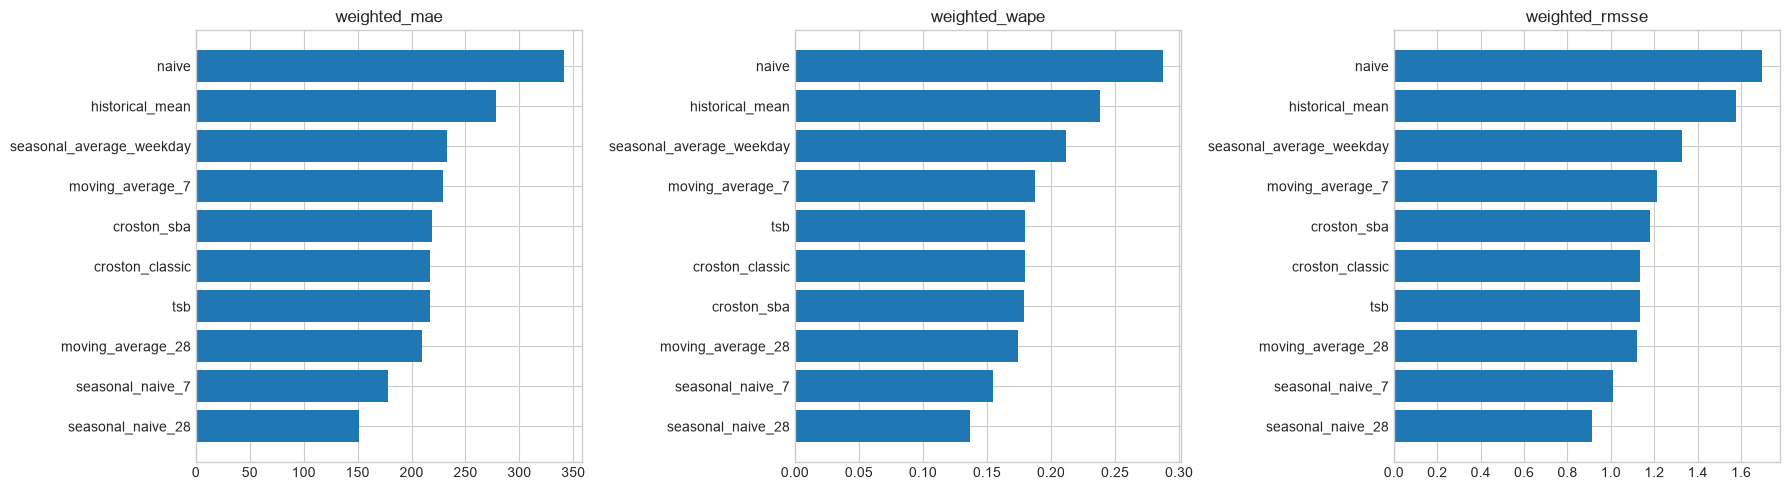

In [3]:
store_summary = summary[summary['dataset'] == 'store_department'].sort_values('weighted_wape')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['weighted_mae', 'weighted_wape', 'weighted_rmsse']):
    ordered = store_summary.sort_values(metric)
    ax.barh(ordered['model'], ordered[metric])
    ax.set_title(metric)
plt.tight_layout()
store_summary

## Real vs Forecast Examples

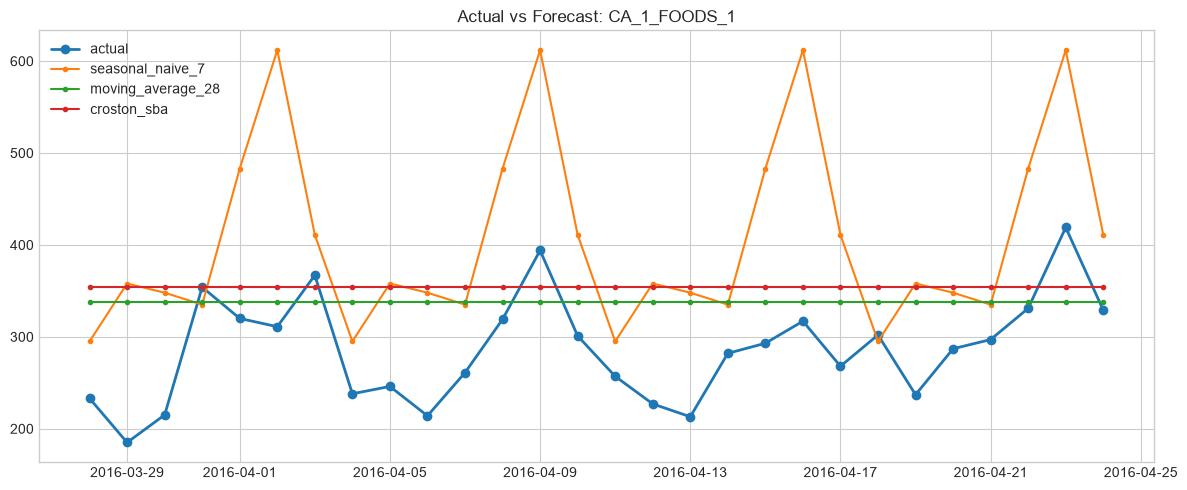

In [4]:
example = store_pred[(store_pred['unique_id'] == store_pred['unique_id'].iloc[0]) & (store_pred['window'] == 'window_3')]
models_to_plot = ['seasonal_naive_7', 'moving_average_28', 'croston_sba']
fig, ax = plt.subplots(figsize=(12, 5))
actual = example[example['model'] == models_to_plot[0]][['forecast_date', 'actual']].drop_duplicates()
ax.plot(actual['forecast_date'], actual['actual'], marker='o', label='actual', linewidth=2)
for model in models_to_plot:
    part = example[example['model'] == model]
    ax.plot(part['forecast_date'], part['prediction'], marker='.', label=model)
ax.set_title(f"Actual vs Forecast: {example['unique_id'].iloc[0]}")
ax.legend()
plt.tight_layout()

## Results By Demand Pattern

,demand_pattern,model,mean_mae,median_mae,weighted_mae,mean_rmse,median_rmse,weighted_rmse,mean_wape,median_wape,weighted_wape,mean_rmsse,median_rmsse,weighted_rmsse,mean_smape,median_smape,weighted_smape,series_count,actual_volume
1,Erratic,croston_sba,8.752332,7.901498,11.298369,10.837650,9.681141,14.065230,1.369299,0.565004,0.534484,0.632610,0.552720,0.807091,74.774600,62.413981,55.441260,25,34223.0
9,Erratic,tsb,8.798321,7.986593,11.337448,10.826151,9.839675,13.999855,1.469615,0.579233,0.538248,0.631294,0.556659,0.803253,74.512885,62.361360,55.127711,25,34223.0
0,Erratic,croston_classic,8.862703,7.960553,11.366329,10.877879,10.080189,14.026773,1.418923,0.579159,0.541121,0.634794,0.555414,0.804739,74.617628,62.361366,55.223227,25,34223.0
3,Erratic,moving_average_28,8.941224,7.964286,11.491919,10.955906,10.362806,14.174932,1.184702,0.582729,0.546199,0.635515,0.577344,0.809646,72.104035,62.625233,55.079298,25,34223.0
4,Erratic,moving_average_7,8.963878,7.862245,11.563629,11.099875,9.226459,14.342807,1.112095,0.599312,0.549810,0.646938,0.556193,0.822791,74.416071,63.479017,57.544608,25,34223.0
8,Erratic,seasonal_naive_7,10.228095,9.964286,12.778755,13.064099,12.946318,16.329542,1.221466,0.678208,0.627385,0.758105,0.729799,0.927420,77.411673,74.330797,65.670359,25,34223.0
7,Erratic,seasonal_naive_28,10.880952,10.357143,13.424294,14.151174,13.724327,17.221802,1.340499,0.747819,0.665225,0.813219,0.820775,0.973086,80.462635,77.849779,66.935334,25,34223.0
5,Erratic,naive,11.188095,9.285714,14.845742,13.418227,11.998512,17.773444,1.390835,0.621145,0.686527,0.792883,0.695931,1.021397,80.283294,69.530901,68.298716,25,34223.0
6,Erratic,seasonal_average_weekday,12.962852,11.899392,13.053491,14.902776,13.325500,15.737732,9.814166,0.689365,0.780158,0.894898,0.788856,0.905845,83.452445,70.804891,59.905560,25,34223.0
2,Erratic,historical_mean,13.161352,12.155419,13.424810,15.123944,13.540617,16.409248,9.824576,0.715825,0.792335,0.908005,0.825070,0.944456,84.141058,71.300173,60.826069,25,34223.0


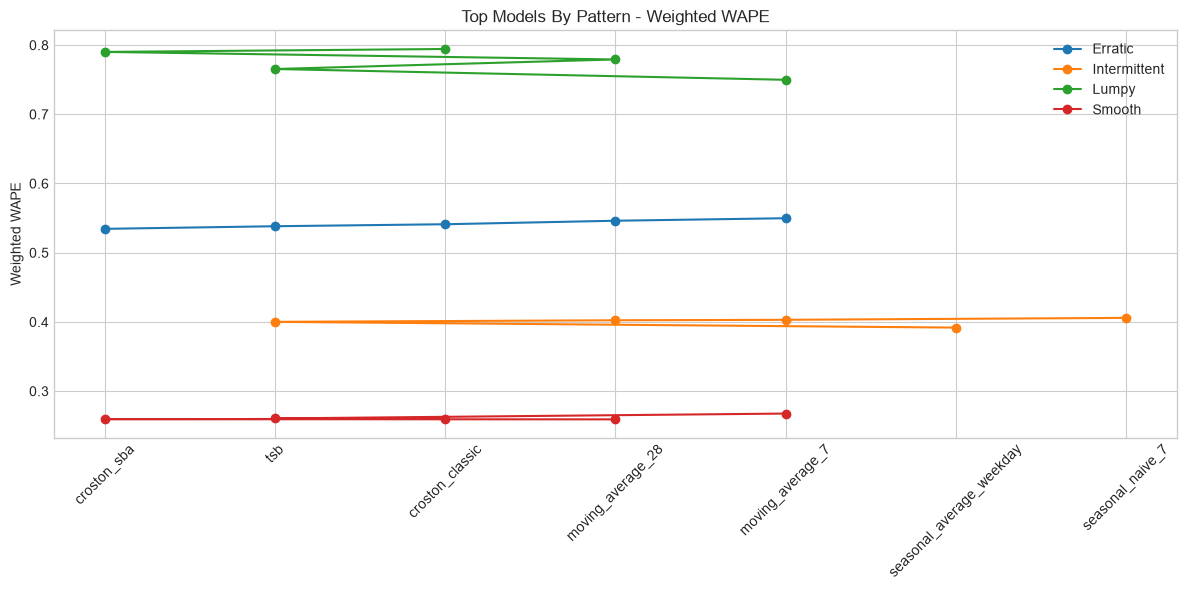

In [5]:
pattern_best = by_pattern.sort_values(['demand_pattern', 'weighted_wape'])
fig, ax = plt.subplots(figsize=(12, 6))
for pattern, group in pattern_best.groupby('demand_pattern'):
    best = group.head(5)
    ax.plot(best['model'], best['weighted_wape'], marker='o', label=pattern)
ax.set_title('Top Models By Pattern - Weighted WAPE')
ax.set_ylabel('Weighted WAPE')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
pattern_best.head(20)

## Results By Horizon

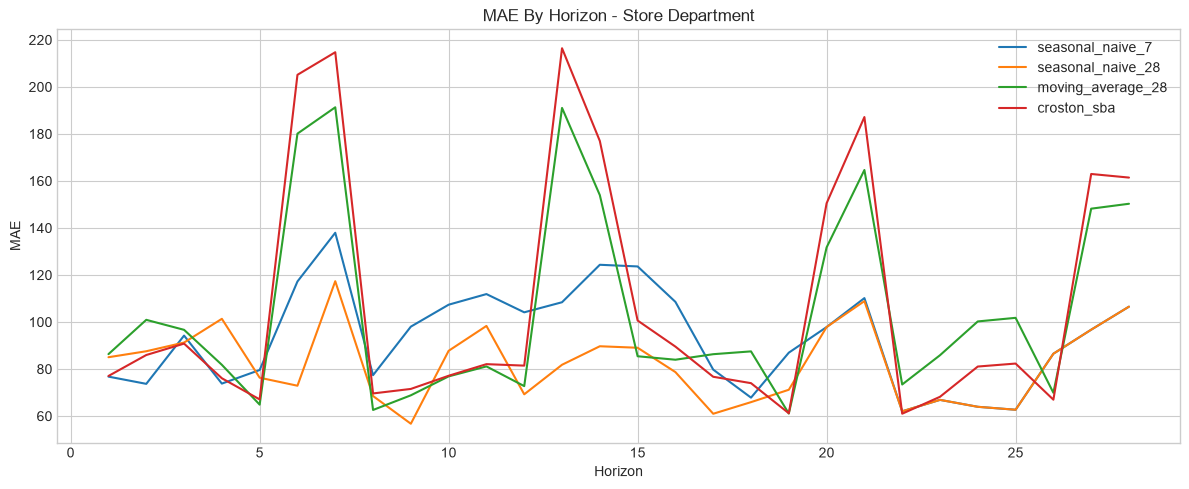

In [6]:
horizon_errors = predictions.assign(abs_error=lambda x: (x['actual'] - x['prediction']).abs())
horizon_summary = horizon_errors.groupby(['dataset', 'model', 'horizon'])['abs_error'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for model in ['seasonal_naive_7', 'seasonal_naive_28', 'moving_average_28', 'croston_sba']:
    part = horizon_summary[(horizon_summary['dataset'] == 'store_department') & (horizon_summary['model'] == model)]
    ax.plot(part['horizon'], part['abs_error'], label=model)
ax.set_title('MAE By Horizon - Store Department')
ax.set_xlabel('Horizon')
ax.set_ylabel('MAE')
ax.legend()
plt.tight_layout()

## Error Distribution

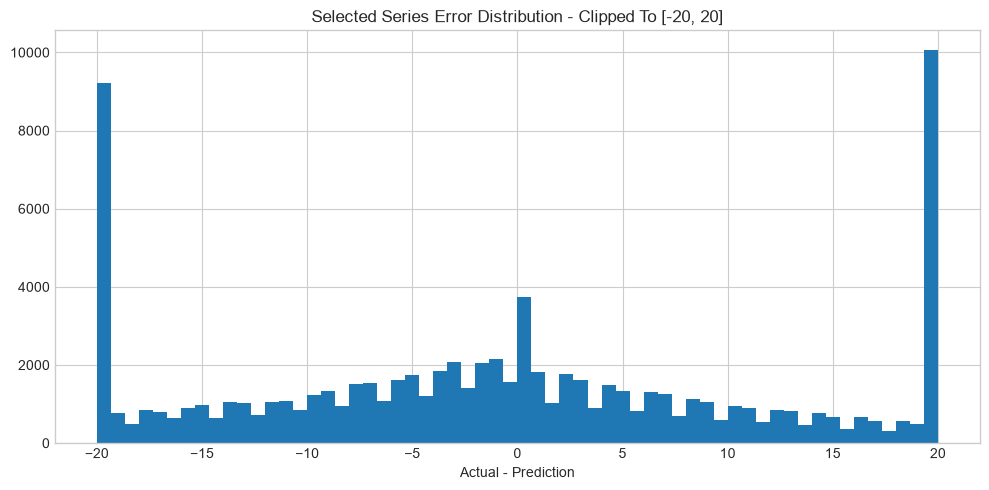

In [7]:
errors = predictions.assign(error=lambda x: x['actual'] - x['prediction'])
fig, ax = plt.subplots(figsize=(10, 5))
errors[errors['dataset'] == 'selected_series']['error'].clip(-20, 20).hist(bins=60, ax=ax)
ax.set_title('Selected Series Error Distribution - Clipped To [-20, 20]')
ax.set_xlabel('Actual - Prediction')
plt.tight_layout()

## Heatmap Model vs Pattern

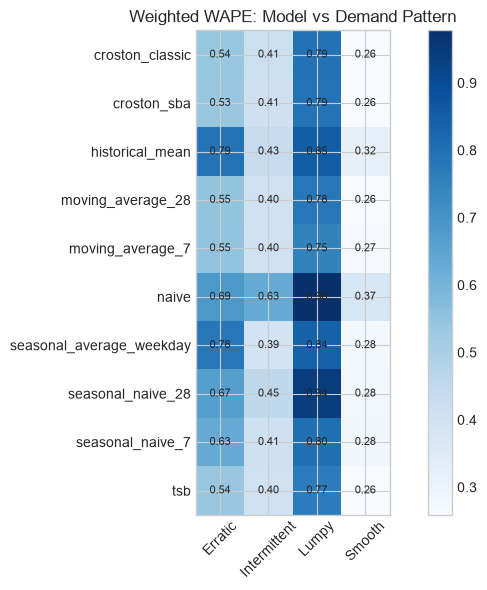

In [8]:
heat = by_pattern.pivot(index='model', columns='demand_pattern', values='weighted_wape')
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heat.values, cmap='Blues')
ax.set_xticks(range(len(heat.columns)), heat.columns, rotation=45)
ax.set_yticks(range(len(heat.index)), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title('Weighted WAPE: Model vs Demand Pattern')
plt.tight_layout()

## Where Intermittent Methods Help Or Fail

In [9]:
intermittent_models = metrics[metrics['model'].isin(['croston_classic', 'croston_sba', 'tsb'])]
simple_models = metrics[metrics['model'].isin(['seasonal_naive_7', 'moving_average_28', 'historical_mean'])]
intermittent_best = intermittent_models.sort_values('wape').groupby(['dataset', 'unique_id']).head(1)
simple_best = simple_models.sort_values('wape').groupby(['dataset', 'unique_id']).head(1)
comparison = intermittent_best.merge(simple_best, on=['dataset', 'unique_id'], suffixes=('_intermittent', '_simple'))
comparison['wape_delta'] = comparison['wape_simple'] - comparison['wape_intermittent']
comparison.sort_values('wape_delta', ascending=False)[['dataset', 'unique_id', 'model_intermittent', 'wape_intermittent', 'model_simple', 'wape_simple', 'wape_delta']].head(10)

,dataset,unique_id,model_intermittent,wape_intermittent,model_simple,wape_simple,wape_delta
150,selected_series,FOODS_3_234_CA_3_validation,croston_sba,0.549948,historical_mean,0.652714,0.102767
155,selected_series,FOODS_3_498_CA_3_validation,croston_sba,0.620593,moving_average_28,0.690103,0.069510
70,selected_series,FOODS_3_808_CA_3_validation,tsb,0.210943,historical_mean,0.253899,0.042956
95,selected_series,FOODS_3_120_CA_3_validation,tsb,0.254173,seasonal_naive_7,0.290357,0.036184
79,selected_series,FOODS_3_555_TX_3_validation,tsb,0.224252,moving_average_28,0.255442,0.031190
114,selected_series,FOODS_2_276_CA_3_validation,croston_sba,0.291220,moving_average_28,0.321138,0.029919
160,selected_series,FOODS_3_635_CA_1_validation,croston_classic,0.776851,moving_average_28,0.806122,0.029272
130,selected_series,FOODS_3_607_CA_3_validation,tsb,0.364590,moving_average_28,0.393022,0.028432
156,selected_series,FOODS_3_580_WI_2_validation,croston_classic,0.657899,historical_mean,0.685971,0.028072
151,selected_series,FOODS_3_070_WI_2_validation,croston_sba,0.551632,moving_average_28,0.576737,0.025105


## Business Conclusions

- Use store-department baselines as the first operational benchmark.
- Evaluate intermittent methods by demand pattern instead of assuming they win globally.
- Move to ML only after beating simple seasonal and moving-average baselines across multiple windows.